In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from Files import Model
from Files import NEGM
from Files import HelperFunctions
from Files import Estimation



In [2]:
model = Model.DurableBufferStock()
model.modelSetup()
model.createGrids()
model.solve()
model.simulate()

par = model.par
sol = model.sol
sim = model.sim

Number of gridpoints: t = 50 p = 10 n = 30 m = 30
48
47
46
45
44
43
42
41
40
39
38
37
36
35
34
33
32
31
30
29
28
27
26
25
24
23
22
21
20
19
18
17
16
15
14
13
12
11
10
9
8
7
6
5
4
3
2
1
0
Solver time: 622.58 seconds
Simulation time: 466.77 seconds


In [3]:
sol.c.shape

(50, 10, 30, 30)

In [4]:
np.max(sol.a)

10.984760256892924

In [5]:
print(np.isnan(sol.c).sum())

0


In [6]:
10*10*30*30

90000

In [7]:
for t in range(par.T):
    print(
        t,
        f"c: {np.nanmin(sim.c[t,:]):.2f} {np.nanmax(sim.c[t,:]):.2f}",
        f"d: {np.nanmin(sim.d[t,:]):.2f} {np.nanmax(sim.d[t,:]):.2f}",
        f"p: {np.nanmin(sim.p[t,:]):.2f} {np.nanmax(sim.p[t,:]):.2f}",
        f"n: {np.nanmin(sim.n[t,:]):.2f} {np.nanmax(sim.n[t,:]):.2f}",
        f"m: {np.nanmin(sim.m[t,:]):.2f} {np.nanmax(sim.m[t,:]):.2f}"
    )

0 c: 0.26 2.13 d: 0.05 1.72 p: 0.37 2.52 n: 0.29 1.84 m: 0.55 3.05
1 c: 0.27 2.54 d: 0.06 1.52 p: 0.34 2.57 n: 0.04 1.46 m: 0.55 3.54
2 c: 0.25 2.63 d: 0.00 2.95 p: 0.31 3.00 n: 0.05 1.29 m: 0.95 4.55
3 c: 0.22 3.13 d: 0.07 2.19 p: 0.27 3.00 n: 0.00 2.50 m: 0.91 4.44
4 c: 0.21 3.05 d: 0.07 1.71 p: 0.23 3.00 n: 0.06 1.86 m: 0.74 4.71
5 c: 0.20 3.17 d: 0.06 2.54 p: 0.21 3.00 n: 0.06 1.45 m: 1.23 5.00
6 c: 0.20 3.17 d: 0.06 2.54 p: 0.20 3.00 n: 0.05 2.16 m: 1.25 4.92
7 c: 0.19 3.39 d: 0.06 2.67 p: 0.18 3.00 n: 0.05 2.16 m: 0.90 4.97
8 c: 0.18 3.34 d: 0.06 2.67 p: 0.16 3.00 n: 0.05 2.27 m: 1.39 4.96
9 c: 0.18 3.41 d: 0.06 2.89 p: 0.15 3.00 n: 0.05 2.27 m: 1.05 5.39
10 c: 0.18 3.54 d: 0.06 2.90 p: 0.15 3.00 n: 0.05 2.46 m: 1.47 5.36
11 c: 0.18 3.44 d: 0.06 2.97 p: 0.15 3.00 n: 0.05 2.47 m: 0.87 5.41
12 c: 0.17 3.39 d: 0.06 3.00 p: 0.13 3.00 n: 0.05 2.52 m: 1.25 5.57
13 c: 0.17 3.49 d: 0.05 2.80 p: 0.13 3.00 n: 0.05 2.55 m: 1.44 4.89
14 c: 0.15 3.47 d: 0.01 2.53 p: 0.10 3.00 n: 0.05 2.38 m: 

In [8]:
print(f"{np.nanmin(par.sim_p_ini):.2f} {np.nanmax(par.sim_p_ini):.2f} {np.mean(par.sim_p_ini):.2f}")
print(f"{np.nanmin(par.sim_d_ini):.2f} {np.nanmax(par.sim_d_ini):.2f} {np.mean(par.sim_d_ini):.2f}")
print(f"{np.nanmin(par.sim_a_ini):.2f} {np.nanmax(par.sim_a_ini):.2f} {np.mean(par.sim_a_ini):.2f}")

0.43 2.17 1.02
0.34 2.17 0.82
0.12 0.31 0.20


In [9]:
for t in range(par.T):

    p_max = par.grid_p[t,-1]
    n_max = par.grid_n[t,-1]
    m_max = par.grid_m[t,-1]

    print(
        t,
        f"p max: {np.nanmax(sim.p[t,:]):.2f}",
        f"at upper bound: {np.sum(sim.p[t,:] >= p_max):,}",

        f"n max: {np.nanmax(sim.n[t,:]):.2f}",
        f"at upper bound: {np.sum(sim.n[t,:] >= n_max):,}",

        f"m max: {np.nanmax(sim.m[t,:]):.2f}",
        f"at upper bound: {np.sum(sim.m[t,:] >= m_max):,}"
    )

0 p max: 2.52 at upper bound: 0 n max: 1.84 at upper bound: 0 m max: 3.05 at upper bound: 0
1 p max: 2.57 at upper bound: 0 n max: 1.46 at upper bound: 0 m max: 3.54 at upper bound: 0
2 p max: 3.00 at upper bound: 1 n max: 1.29 at upper bound: 0 m max: 4.55 at upper bound: 0
3 p max: 3.00 at upper bound: 3 n max: 2.50 at upper bound: 0 m max: 4.44 at upper bound: 0
4 p max: 3.00 at upper bound: 7 n max: 1.86 at upper bound: 0 m max: 4.71 at upper bound: 0
5 p max: 3.00 at upper bound: 11 n max: 1.45 at upper bound: 0 m max: 5.00 at upper bound: 0
6 p max: 3.00 at upper bound: 21 n max: 2.16 at upper bound: 0 m max: 4.92 at upper bound: 0
7 p max: 3.00 at upper bound: 39 n max: 2.16 at upper bound: 0 m max: 4.97 at upper bound: 0
8 p max: 3.00 at upper bound: 39 n max: 2.27 at upper bound: 0 m max: 4.96 at upper bound: 0
9 p max: 3.00 at upper bound: 50 n max: 2.27 at upper bound: 0 m max: 5.39 at upper bound: 0
10 p max: 3.00 at upper bound: 71 n max: 2.46 at upper bound: 0 m max: 5.36

In [10]:
#print("n = ", par.grid_n[5,49].round(3), "m = ",par.grid_m[5,59].round(3))
#for p in range(20):
 #   u = HelperFunctions.utility(sol.c[5,p,49,59], sol.d[5,p,49,59], par)
  #  print("p =",par.grid_p[5,p].round(3), "d =" ,sol.d[5,p,49,59].round(3), "c =", sol.c[5,p,49,59].round(3), "u =", u.round(3))

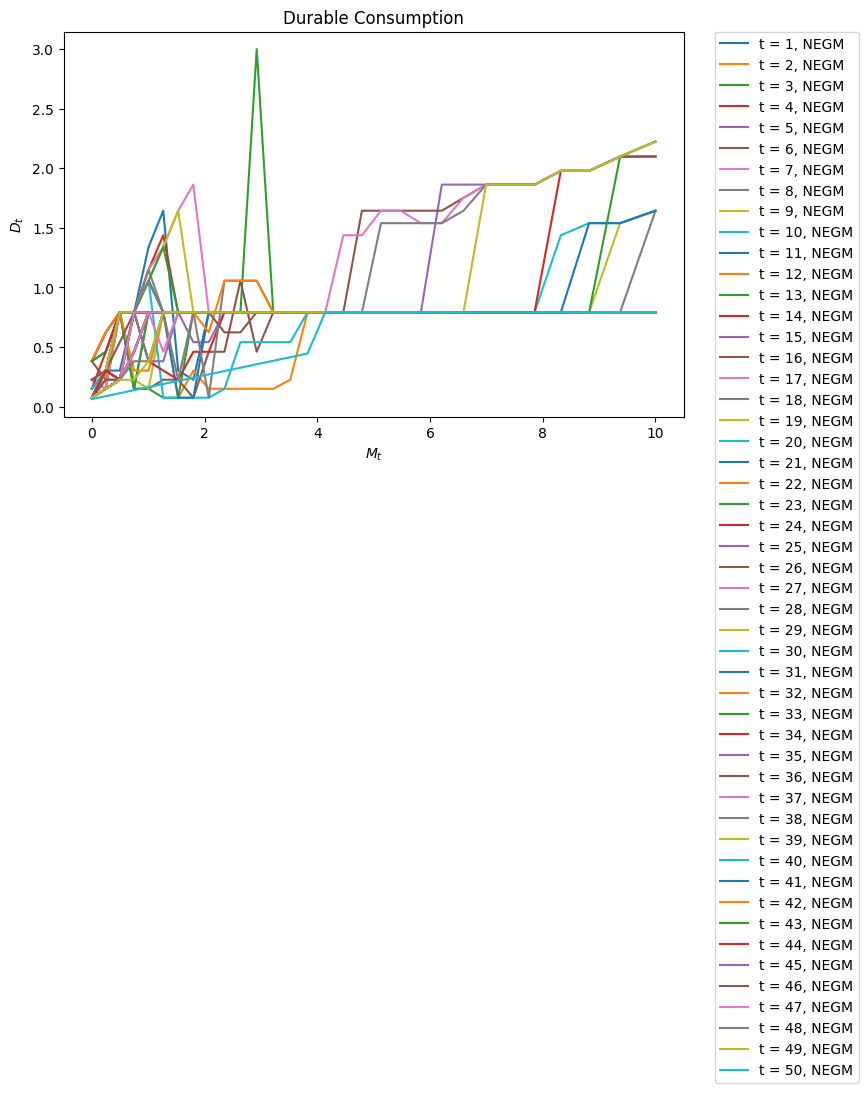

In [11]:
fig = plt.figure(figsize=(8,5))# figsize is in inches...
ax = fig.add_subplot(1,1,1)
for t in range(par.T):

    ax.plot(sol.m[t, 5, 10, :],sol.d[t, 5, 10, :],  label=f"t = {t + 1}, NEGM",  linestyle='-')

ax.set_xlabel(f"$M_t$")
ax.set_ylabel(f"$D_t$")
ax.set_title(f'Durable Consumption')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.show()

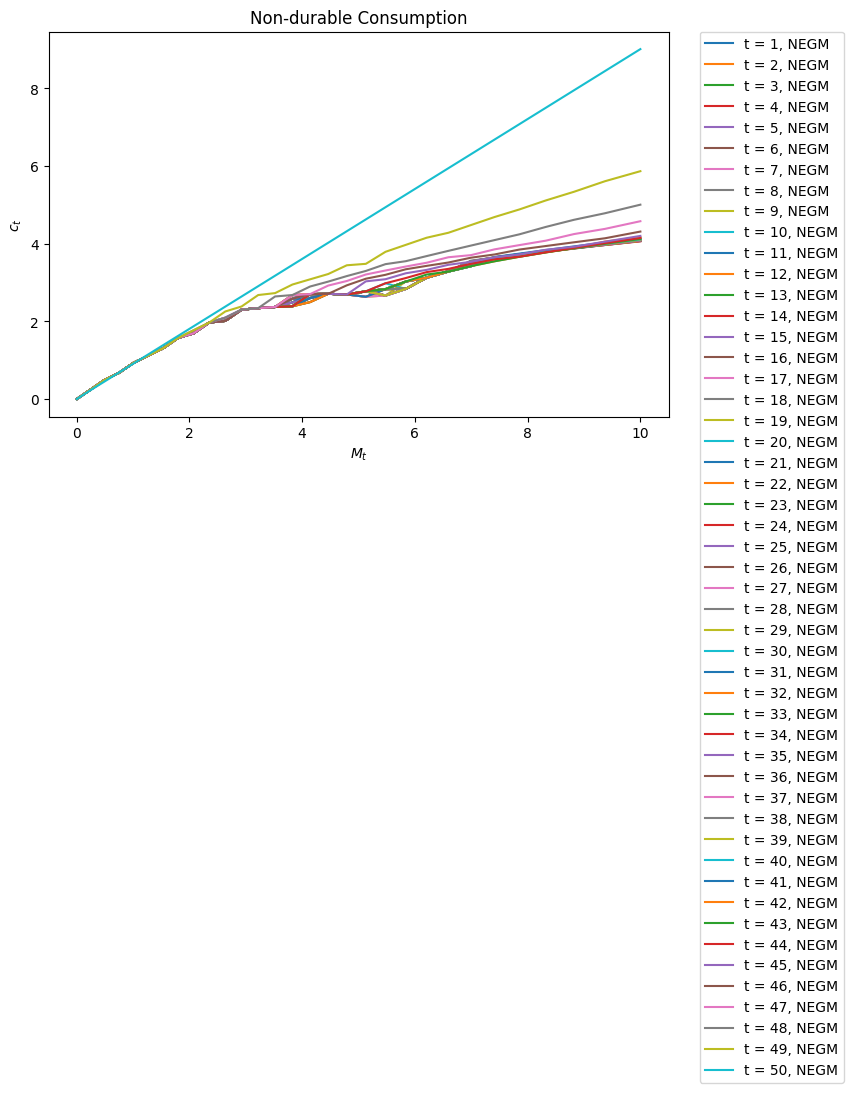

In [12]:
fig = plt.figure(figsize=(8,5))# figsize is in inches...
ax = fig.add_subplot(1,1,1)
for t in range(par.T):
    ax.plot(sol.m[t, 9, 0, :],sol.c[t, 9, 0, :],  label=f"t = {t + 1}, NEGM",  linestyle='-')

ax.set_xlabel(f"$M_t$")
ax.set_ylabel(f"$c_t$")
ax.set_title(f'Non-durable Consumption')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.show()

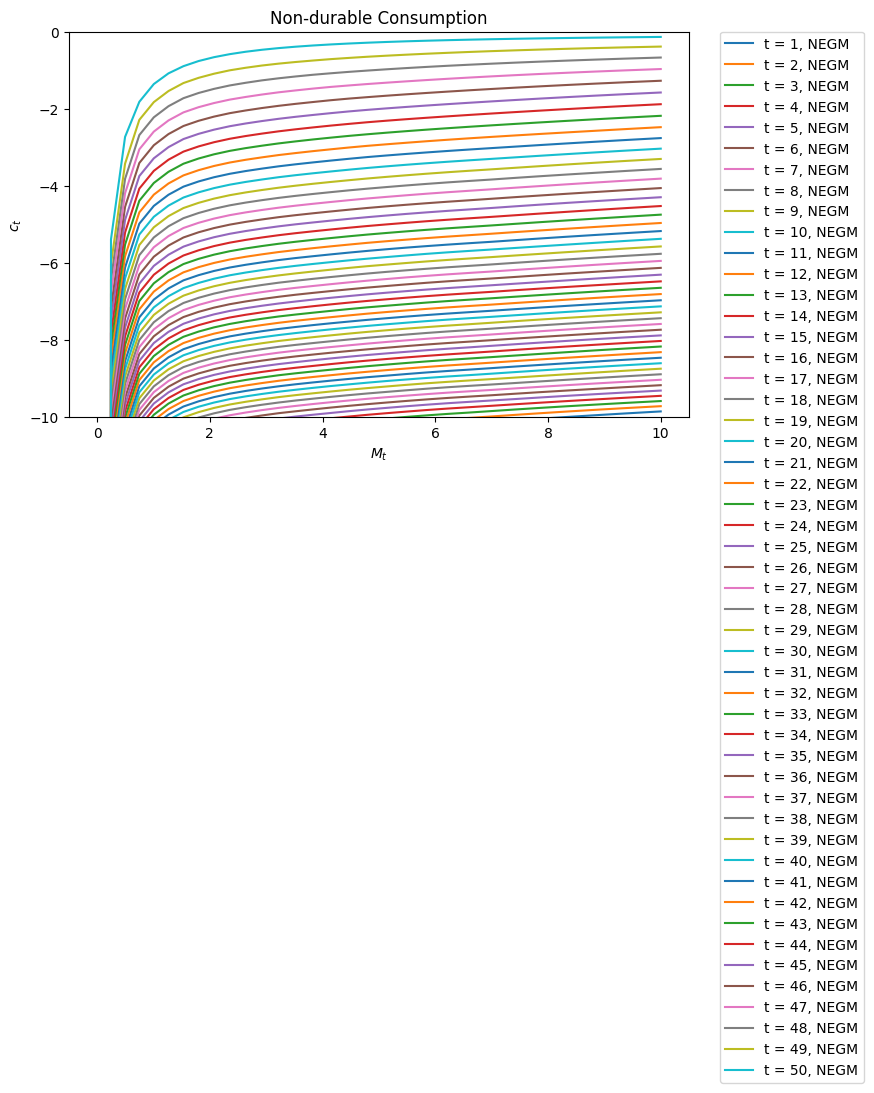

In [13]:
fig = plt.figure(figsize=(8,5))# figsize is in inches...
ax = fig.add_subplot(1,1,1)
for t in range(par.T):
    ax.plot(sol.m[t, 9, 0, :],sol.v[t, 9, 0, :],  label=f"t = {t + 1}, NEGM",  linestyle='-')

ax.set_xlabel(f"$M_t$")
ax.set_ylabel(f"$c_t$")
ax.set_title(f'Non-durable Consumption')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
ax.set_ylim(bottom=-10,top=0)
plt.show()

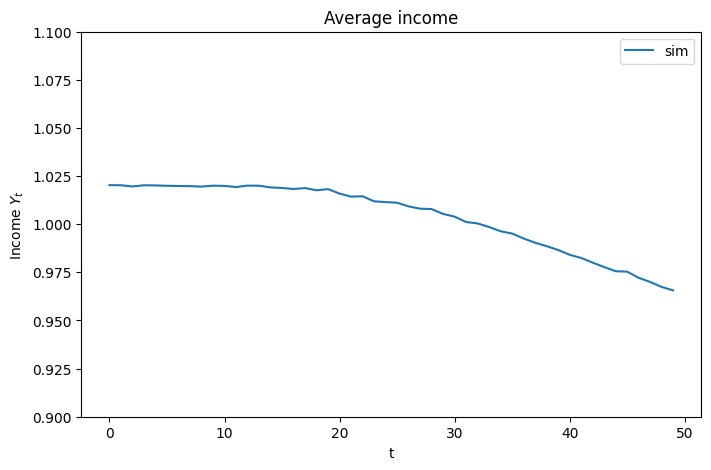

In [14]:
fig = plt.figure(figsize=(8,5))
ax = fig.add_subplot(1,1,1)
ax.plot(np.arange(par.T), np.mean(sim.y, axis=1), label='sim')
ax.set_xlabel(f"t")
ax.set_ylabel(f"Income $Y_t$")
ax.set_title(f'Average income')
ax.legend()
ax.set_ylim(bottom=0.9,top=1.1)
plt.show()

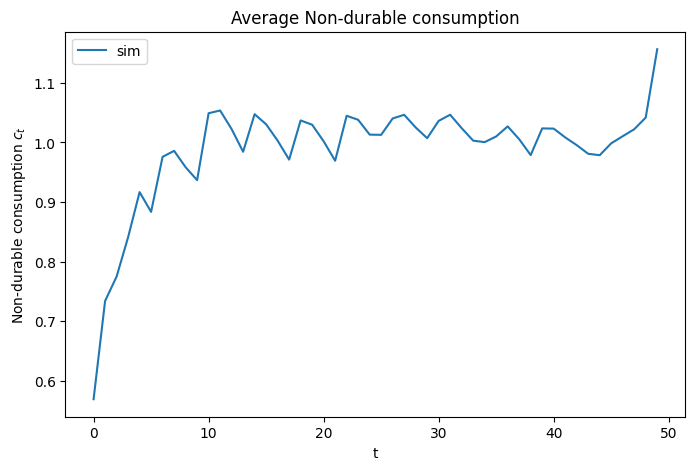

0.5690424006173699
0.7338793231719439


In [15]:
fig = plt.figure(figsize=(8,5))
ax = fig.add_subplot(1,1,1)
ax.plot(np.arange(par.T), np.mean(sim.c, axis=1), label='sim')
ax.set_xlabel(f"t")
ax.set_ylabel(f"Non-durable consumption $c_t$")
ax.set_title(f'Average Non-durable consumption')
ax.legend()
#ax.set_ylim(bottom=0.5,top=1.5)
plt.show()

print(np.mean(sim.c[0]))
print(np.mean(sim.c[1]))

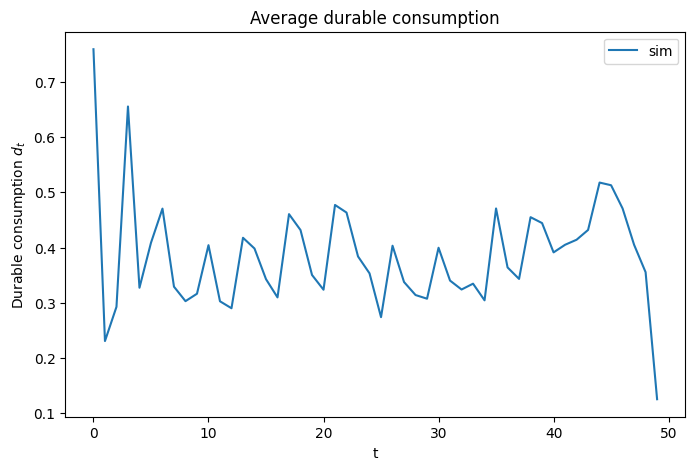

In [16]:
fig = plt.figure(figsize=(8,5))
ax = fig.add_subplot(1,1,1)
ax.plot(np.arange(par.T), np.mean(sim.d, axis=1), label='sim')
ax.set_xlabel(f"t")
ax.set_ylabel(f"Durable consumption $d_t$")
ax.set_title(f'Average durable consumption')
ax.legend()
plt.show()

In [17]:
np.mean(sim.c)

0.9873899031027948

In [18]:
np.var(sim.c)

0.2587633964278847

In [19]:
np.mean(sim.d)

0.3849749052158612

In [20]:
np.var(sim.d)

0.09738944895442124